In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from astropy.io import fits
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 26
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'stix'

In [3]:
fname = "DR19seisages_samp_train456789_net10_method14151617_cluster1819_LTt23k_WRC.fits"

with fits.open(fname, memmap=True) as hdul:
    cols = hdul["STARFLOW_TABLE"].columns.names
    print(len(cols))
    print(cols)

452
['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id', 'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id', 'catalogid', 'catalogid21', 'catalogid25', 'catalogid31', 'n_associated', 'n_neighborhood', 'sdss5_target_flags', 'sdss4_apogee_target1_flags', 'sdss4_apogee_target2_flags', 'sdss4_apogee2_target1_flags', 'sdss4_apogee2_target2_flags', 'sdss4_apogee2_target3_flags', 'sdss4_apogee_member_flags', 'sdss4_apogee_extra_target_flags', 'ra', 'dec', 'l', 'b', 'plx', 'e_plx', 'pmra', 'e_pmra', 'pmde', 'e_pmde', 'gaia_v_rad', 'gaia_e_v_rad', 'g_mag', 'bp_mag', 'rp_mag', 'j_mag', 'e_j_mag', 'h_mag', 'e_h_mag', 'k_mag', 'e_k_mag', 'ph_qual', 'bl_flg', 'cc_flg', 'w1_mag', 'e_w1_mag', 'w1_flux', 'w1_dflux', 'w1_frac', 'w2_mag', 'e_w2_mag', 'w2_flux', 'w2_dflux', 'w2_frac', 'w1uflags', 'w2uflags', 'w1aflags', 'w2aflags', 'mag4_5', 'd4_5m', 'rms_f4_5', 'sqf_4_5', 'mf4_5', 'csf', 'zgr_teff', 'zgr_e_teff', 'zgr_logg', 'zgr_e_logg', 'zgr_fe_h', 'zgr_e_fe_h', 'zgr_e', 'zgr_e_e', 'zg

In [4]:
with fits.open(fname, memmap=True) as hdul:
    data = hdul["STARFLOW_TABLE"].data

In [5]:
feh_col = "fe_h"
ap3_col = "LT_AP3_Net2_Age"
ak2_col = "LT_AK2_Net2_Age"
apok2_lit_col = "APOK2_Age_W24_incRC"

teff_col  = "teff"
logg_col  = "logg"
alpha_col = "alpha_m_atm"

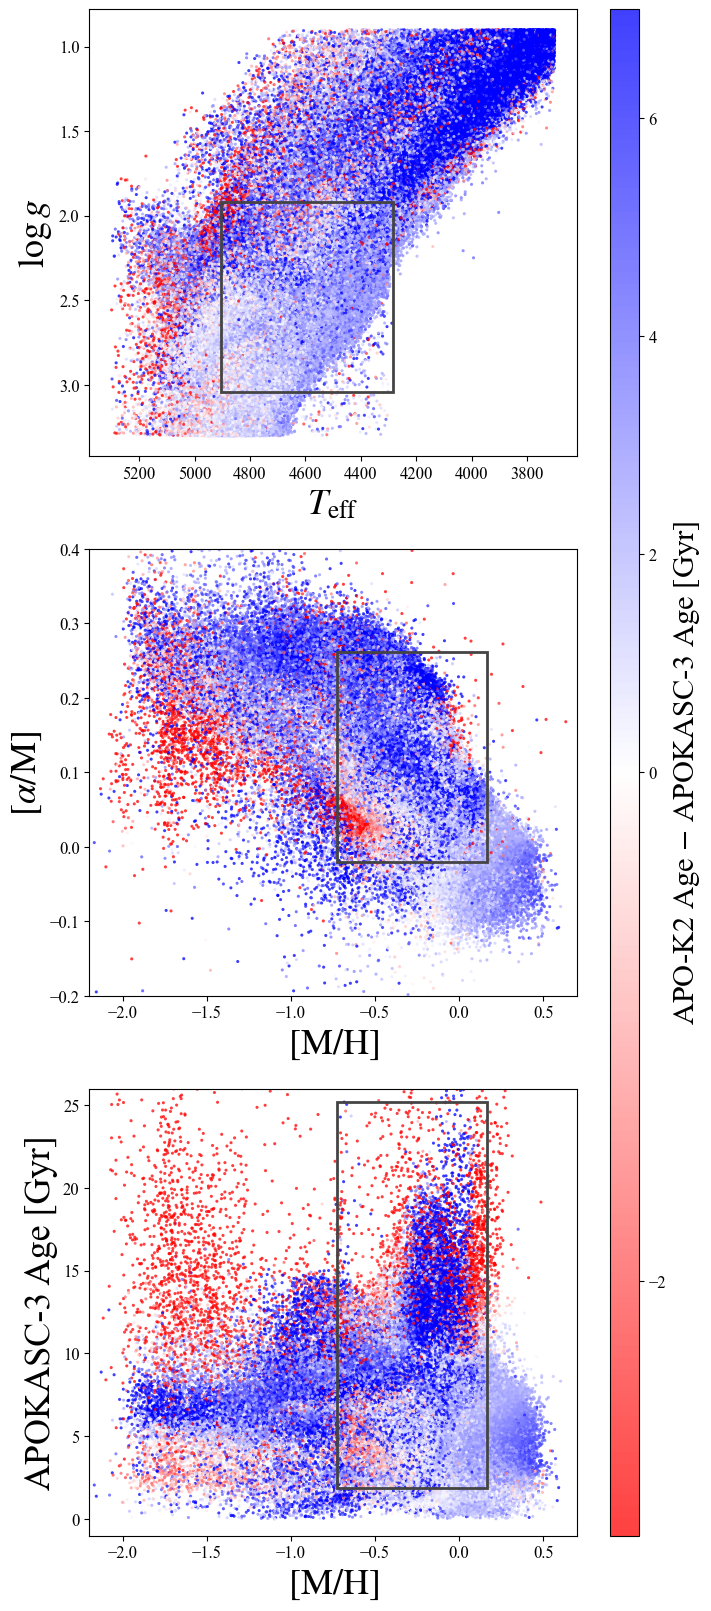

In [6]:
delta_age = data[ak2_col] - data[ap3_col]

ref = (
    np.isfinite(data[apok2_lit_col]) & (data[apok2_lit_col] > 0) &
    np.isfinite(data[teff_col]) &
    np.isfinite(data[logg_col]) &
    np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
    np.isfinite(data[alpha_col])
)

teff_p5,  teff_p95  = np.nanpercentile(data[teff_col][ref],  [5, 95])
logg_p5,  logg_p95  = np.nanpercentile(data[logg_col][ref],  [5, 95])
feh_p5,   feh_p95   = np.nanpercentile(data[feh_col][ref],   [5, 95])
alpha_p5, alpha_p95 = np.nanpercentile(data[alpha_col][ref], [5, 95])
ak2_lit_p5, ak2_lit_p95 = np.nanpercentile(data[apok2_lit_col][ref], [5, 95])

m = (
    np.isfinite(data[ap3_col]) & np.isfinite(data[ak2_col]) &
    (data[ap3_col] > 0) & (data[ak2_col] > 0) &
    np.isfinite(data[feh_col])  & (data[feh_col] != -9999) &
    np.isfinite(data[teff_col]) &
    np.isfinite(data[logg_col]) &
    np.isfinite(data[alpha_col])
)

teff  = np.asarray(data[teff_col][m], dtype=float)
logg  = np.asarray(data[logg_col][m], dtype=float)
feh   = np.asarray(data[feh_col][m], dtype=float)
alpha = np.asarray(data[alpha_col][m], dtype=float)
ap3   = np.asarray(data[ap3_col][m], dtype=float)
dage  = np.asarray(delta_age[m], dtype=float)

in_box1 = (
    (teff >= teff_p5) & (teff <= teff_p95) &
    (logg >= logg_p5) & (logg <= logg_p95)
)

in_box2 = (
    (feh >= feh_p5) & (feh <= feh_p95) &
    (alpha >= alpha_p5) & (alpha <= alpha_p95)
)

in_box3 = (
    (feh >= feh_p5) & (feh <= feh_p95) &
    (ap3 >= ak2_lit_p5) & (ap3 <= ak2_lit_p95)
)

fig = plt.figure(figsize=(7, 16), constrained_layout=True)

gs = fig.add_gridspec(
    3, 3,
    width_ratios=[1, 0.05, 0.06],
    height_ratios=[1, 1, 1]
)

axes = [fig.add_subplot(gs[i, 0]) for i in range(3)]
cax = fig.add_subplot(gs[:, 2])

cmap = "bwr_r"
norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=7)

pt_size = 5
pt_alpha = 0.75
box_color = "#444444"

sc1 = axes[0].scatter(
    teff, logg,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect1 = Rectangle(
    (teff_p5, logg_p5),
    teff_p95 - teff_p5,
    logg_p95 - logg_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[0].add_patch(rect1)

axes[0].set_xlabel(r"$T_{\mathrm{eff}}$")
axes[0].set_ylabel(r"$\log g$")
axes[0].invert_xaxis()
axes[0].invert_yaxis()

sc2 = axes[1].scatter(
    feh, alpha,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect2 = Rectangle(
    (feh_p5, alpha_p5),
    feh_p95 - feh_p5,
    alpha_p95 - alpha_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[1].add_patch(rect2)

axes[1].set_xlabel(r"$[\mathrm{M}/\mathrm{H}]$")
axes[1].set_ylabel(r"$[\alpha/\mathrm{M}]$")
axes[1].set_xlim(-2.2, 0.7)
axes[1].set_ylim(-0.2, 0.4)

sc3 = axes[2].scatter(
    feh, ap3,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect3 = Rectangle(
    (feh_p5, ak2_lit_p5),
    feh_p95 - feh_p5,
    ak2_lit_p95 - ak2_lit_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[2].add_patch(rect3)

axes[2].set_xlabel(r"$[\mathrm{M}/\mathrm{H}]$")
axes[2].set_ylabel("APOKASC-3 Age [Gyr]")
axes[2].set_xlim(-2.2, 0.7)
axes[2].set_ylim(-1, 26)

cbar = fig.colorbar(sc3, cax=cax)
cbar.set_label(r"APO-K2 Age $-$ APOKASC-3 Age [Gyr]", fontsize=22)

plt.show()

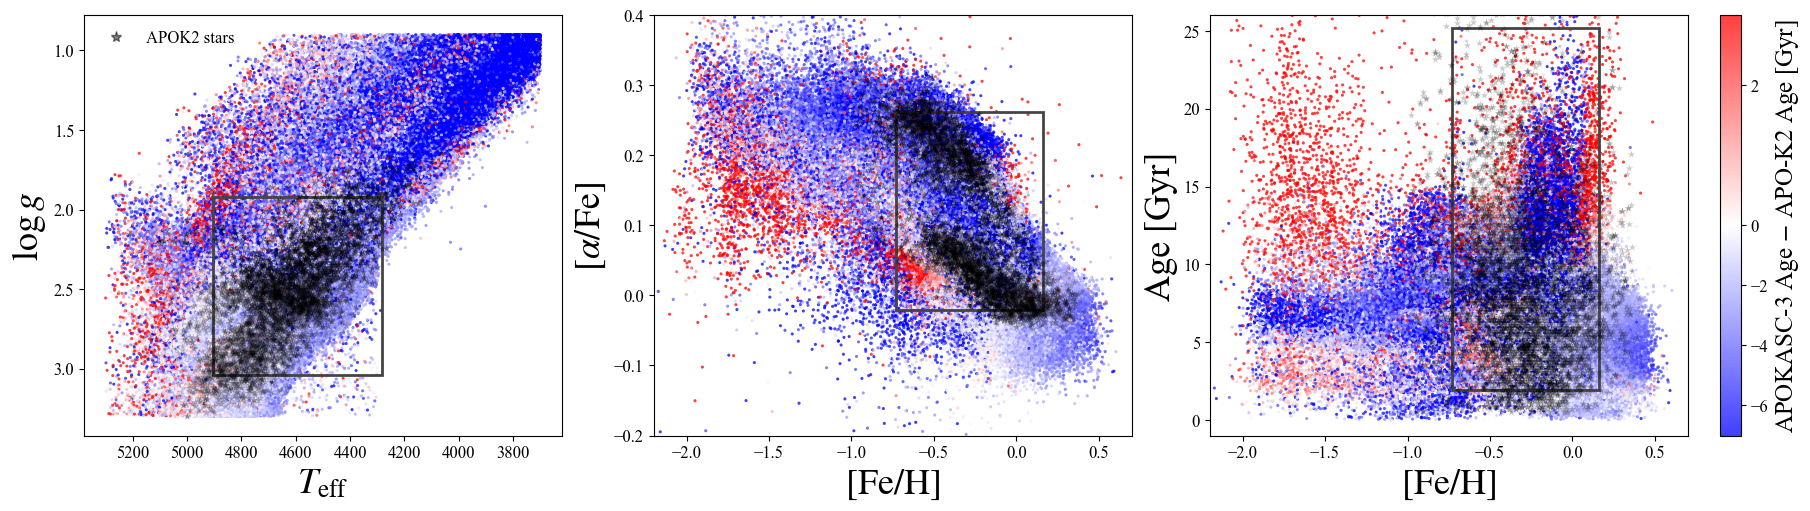

In [7]:
delta_age = data[ap3_col] - data[ak2_col]

ref = (
    np.isfinite(data[apok2_lit_col]) & (data[apok2_lit_col] > 0) &
    np.isfinite(data[teff_col]) &
    np.isfinite(data[logg_col]) &
    np.isfinite(data[feh_col]) & (data[feh_col] != -9999) &
    np.isfinite(data[alpha_col])
)

teff_p5,  teff_p95  = np.nanpercentile(data[teff_col][ref],  [5, 95])
logg_p5,  logg_p95  = np.nanpercentile(data[logg_col][ref],  [5, 95])
feh_p5,   feh_p95   = np.nanpercentile(data[feh_col][ref],   [5, 95])
alpha_p5, alpha_p95 = np.nanpercentile(data[alpha_col][ref], [5, 95])
ak2_lit_p5, ak2_lit_p95 = np.nanpercentile(data[apok2_lit_col][ref], [5, 95])

m = (
    np.isfinite(data[ap3_col]) & np.isfinite(data[ak2_col]) &
    (data[ap3_col] > 0) & (data[ak2_col] > 0) &
    np.isfinite(data[feh_col])  & (data[feh_col] != -9999) &
    np.isfinite(data[teff_col]) &
    np.isfinite(data[logg_col]) &
    np.isfinite(data[alpha_col])
)

teff  = np.asarray(data[teff_col][m], dtype=float)
logg  = np.asarray(data[logg_col][m], dtype=float)
feh   = np.asarray(data[feh_col][m], dtype=float)
alpha = np.asarray(data[alpha_col][m], dtype=float)
ap3   = np.asarray(data[ap3_col][m], dtype=float)
dage  = np.asarray(delta_age[m], dtype=float)

apok2_age = np.asarray(data[apok2_lit_col][m], dtype=float)

apok2_stars = np.asarray(
    np.isfinite(apok2_age) & (apok2_age > 0),
    dtype=bool
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

cmap = "bwr"
norm = TwoSlopeNorm(vmin=-7, vcenter=0, vmax=3)

pt_size = 5
pt_alpha = 0.75
box_color = "#444444"

star_size = 30
star_alpha = 0.20

sc1 = axes[0].scatter(
    teff, logg,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect1 = Rectangle(
    (teff_p5, logg_p5),
    teff_p95 - teff_p5,
    logg_p95 - logg_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[0].add_patch(rect1)

axes[0].scatter(
    teff[apok2_stars], logg[apok2_stars],
    marker='*', s=star_size, c='black', alpha=star_alpha,
    linewidths=0, zorder=4
)

axes[0].set_xlabel(r"$T_{\mathrm{eff}}$")
axes[0].set_ylabel(r"$\log g$")
axes[0].invert_xaxis()
axes[0].invert_yaxis()

legend_handle = Line2D(
    [0], [0],
    marker='*',
    linestyle='None',
    color='black',
    markerfacecolor='black',
    markeredgecolor='black',
    markersize=8,
    alpha=0.5,
    label='APOK2 stars'
)

axes[0].legend(
    handles=[legend_handle],
    frameon=False,
    loc='upper left'
)

sc2 = axes[1].scatter(
    feh, alpha,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect2 = Rectangle(
    (feh_p5, alpha_p5),
    feh_p95 - feh_p5,
    alpha_p95 - alpha_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[1].add_patch(rect2)

axes[1].scatter(
    feh[apok2_stars], alpha[apok2_stars],
    marker='*', s=star_size, c='black', alpha=star_alpha,
    linewidths=0, zorder=4
)

axes[1].set_xlabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
axes[1].set_ylabel(r"$[\alpha/\mathrm{Fe}]$")
axes[1].set_xlim(-2.2, 0.7)
axes[1].set_ylim(-0.2, 0.4)

sc3 = axes[2].scatter(
    feh, ap3,
    c=dage, s=pt_size, alpha=pt_alpha,
    cmap=cmap, norm=norm,
    edgecolors='none', linewidths=0
)

rect3 = Rectangle(
    (feh_p5, ak2_lit_p5),
    feh_p95 - feh_p5,
    ak2_lit_p95 - ak2_lit_p5,
    fill=False, edgecolor=box_color, linewidth=2.0, zorder=3
)
axes[2].add_patch(rect3)

axes[2].scatter(
    feh[apok2_stars], apok2_age[apok2_stars],
    marker='*', s=star_size, c='black', alpha=star_alpha,
    linewidths=0, zorder=4
)

axes[2].set_xlabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
axes[2].set_ylabel("Age [Gyr]")
axes[2].set_xlim(-2.2, 0.7)
axes[2].set_ylim(-1, 26)

cbar = fig.colorbar(sc3, ax=axes, pad=0.02)
cbar.set_label(r"APOKASC-3 Age $-$ APO-K2 Age [Gyr]", fontsize=18)

plt.show()